In [18]:
import os, sys
import pickle
root = os.path.dirname(os.getcwd())
path = os.path.join(root, "data/final_project_experiments")

try:
    with open(os.path.join(path, f"history_random_0"), "rb") as file:  # 'wb' = write binary
        history_r0 = pickle.load(file)
    with open(os.path.join(path, f"history_curriculum_1"), "rb") as file:  # 'wb' = write binary
        history_c1 = pickle.load(file)
    with open(os.path.join(path, f"history_curriculum_2"), "rb") as file:  # 'wb' = write binary
        history_c2 = pickle.load(file)
    with open(os.path.join(path, f"history_anti-curriculum_1"), "rb") as file:  # 'wb' = write binary
        history_ac1 = pickle.load(file)
    with open(os.path.join(path, f"history_anti-curriculum_2"), "rb") as file:  # 'wb' = write binary
        history_ac2 = pickle.load(file)
    with open(os.path.join(path, f"history_rand_curriculum_1"), "rb") as file:  # 'wb' = write binary
        history_rc1 = pickle.load(file)
    with open(os.path.join(path, f"history_rand-curriculum_2"), "rb") as file:  # 'wb' = write binary
        history_rc2 = pickle.load(file)
    print("Dictionaries loaded successfully.")
except (OSError, pickle.PickleError) as e:
    print(f"Error loading dictionary: {e}")

Dictionaries loaded successfully.


In [19]:
def hist_combine(history, pacing=True, B=False):
    combined_hist = {"train_loss": [], "test_nll": [], "singular_entropy": [], "anisotropy": []}
    if pacing and not B:
        for key in combined_hist.keys():
            combined_hist[key] = history["easy"][key] + history["medium"][key] + history["hard"][key] + history["mixed"][key]
    elif pacing and B:
        for key in combined_hist.keys():
            combined_hist[key] = history["b1"][key] + history["b2"][key] + history["b3"][key] + history["mixed"][key]
    else:
        for key in combined_hist.keys():
            combined_hist[key] = history["hard"][key] + history["medium"][key] + history["easy"][key] + history["mixed"][key]
    return combined_hist

cb_hist_c1 = hist_combine(history_c1)
cb_hist_c2 = hist_combine(history_c2)
cb_hist_ac1 = hist_combine(history_ac1, pacing=False)
cb_hist_ac2 = hist_combine(history_ac2, pacing=False)
cb_hist_rc1 = hist_combine(history_rc1, B=True)
cb_hist_rc2 = hist_combine(history_rc2, B=True)
    

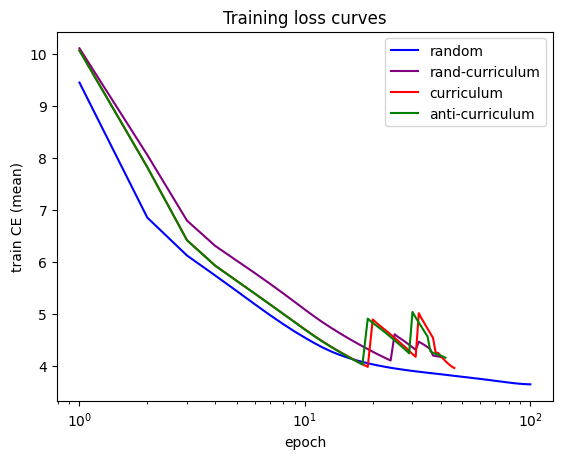

In [20]:
import matplotlib.pyplot as plt
## plot train loss curves
fig, ax = plt.subplots()
ax.plot(range(1, len(history_r0["train_loss"]) + 1), history_r0["train_loss"], color='blue', label='random')
ax.plot(range(1, len(cb_hist_rc1["train_loss"]) + 1), cb_hist_rc1["train_loss"], color='purple', label='rand-curriculum')
ax.plot(range(1, len(cb_hist_c1["train_loss"]) + 1), cb_hist_c1["train_loss"], color='red', label='curriculum')
ax.plot(range(1, len(cb_hist_ac1["train_loss"]) + 1), cb_hist_ac1["train_loss"], color='green', label='anti-curriculum')
ax.set_xscale('log')
ax.set_xlabel("epoch")
ax.set_ylabel("train CE (mean)")
ax.set_title("Training loss curves")
ax.legend()



In [4]:
len(cb_hist_c1["train_loss"])
len(history_r0["train_loss"])


100

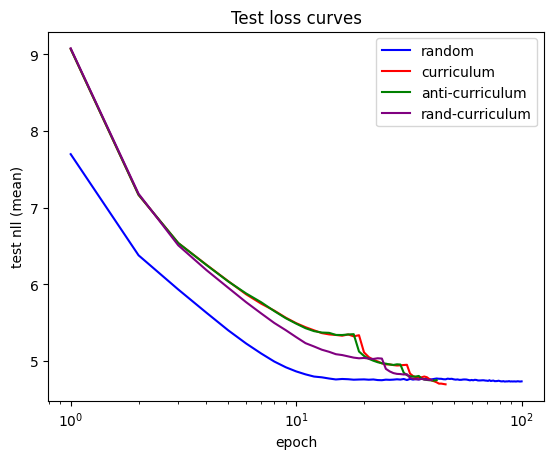

In [25]:
## plot test loss curves
min_ep = min(len(history_r0["test_nll"]), len(cb_hist_c1["test_nll"]), len(cb_hist_ac1["test_nll"]))
fig, ax = plt.subplots()
ax.plot(range(1, len(history_r0["test_nll"]) + 1), history_r0["test_nll"], color='blue', label='random')
ax.plot(range(1, len(cb_hist_c1["test_nll"]) + 1), cb_hist_c1["test_nll"], color='red', label='curriculum')
ax.plot(range(1, len(cb_hist_ac1["test_nll"]) + 1), cb_hist_ac1["test_nll"], color='green', label='anti-curriculum')
ax.plot(range(1, len(cb_hist_rc1["test_nll"]) + 1), cb_hist_rc1["test_nll"], color='purple', label='rand-curriculum')

ax.set_xscale('log')
ax.set_xlabel("epoch")
ax.set_ylabel("test nll (mean)")
ax.set_title("Test loss curves")
ax.legend()


In [22]:
print(history_r0["test_nll"][-1])
print(cb_hist_c1["test_nll"][-1])
print(cb_hist_ac1["test_nll"][-1])
print(cb_hist_rc1["test_nll"][-1])

4.732936038186633
4.694406956058359
4.750269580483808
4.751880556660061


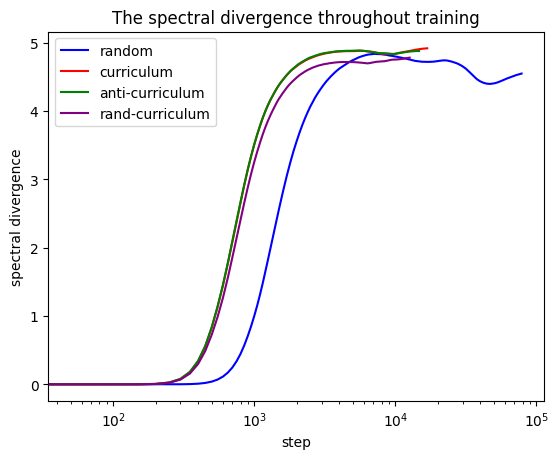

In [23]:
import numpy as np
## plot singular entropies throughout training
fig, ax = plt.subplots()
ax.plot(50 * np.arange(0, len(history_r0["singular_entropy"])), history_r0["singular_entropy"], color='blue', label='random')
ax.plot(50 * np.arange(0, len(cb_hist_c1["singular_entropy"])), cb_hist_c1["singular_entropy"], color='red', label='curriculum')
ax.plot(50 * np.arange(0, len(cb_hist_ac1["singular_entropy"])), cb_hist_ac1["singular_entropy"], color='green', label='anti-curriculum')
ax.plot(50 * np.arange(0, len(cb_hist_rc1["singular_entropy"])), cb_hist_rc1["singular_entropy"], color='purple', label='rand-curriculum')
ax.set_xscale('log')
ax.set_xlabel("step")
ax.set_ylabel("spectral divergence")
ax.set_title("The spectral divergence throughout training")
ax.legend()


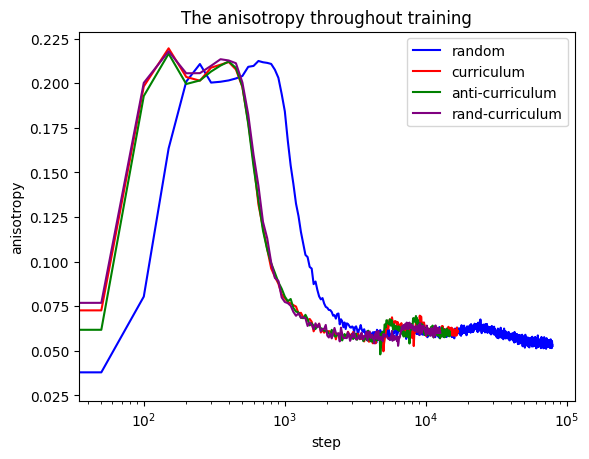

In [24]:
## plot anisotropy throughout training
fig, ax = plt.subplots()
ax.plot(50 * np.arange(0, len(history_r0["anisotropy"])), history_r0["anisotropy"], color='blue', label='random')
ax.plot(50 * np.arange(0, len(cb_hist_c1["anisotropy"])), cb_hist_c1["anisotropy"], color='red', label='curriculum')
ax.plot(50 * np.arange(0, len(cb_hist_ac1["anisotropy"])), cb_hist_ac1["anisotropy"], color='green', label='anti-curriculum')
ax.plot(50 * np.arange(0, len(cb_hist_rc1["anisotropy"])), cb_hist_rc1["anisotropy"], color='purple', label='rand-curriculum')

ax.set_xscale('log')
ax.set_xlabel("step")
ax.set_ylabel("anisotropy")
ax.set_title("The anisotropy throughout training")
ax.legend()

In [26]:
import random
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer
from tqdm import tqdm

import torch
from torch.utils.data import DataLoader, TensorDataset

import os, sys

import unicodedata
import re
from collections import Counter

def set_seed(seed: int = 0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

root = os.path.dirname(os.getcwd())
data_path = os.path.join(root, "data/final_project_experiments")

if path not in sys.path:
  sys.path.append(path)

def corpus_statistics(text):
    """
    Compute the unigram/single word frequency count (unigram),
    the bigram/word-tuple frequency count (bigram),
    the total number of words in the corpus (corpus_size),
    and the number of unique-words in the corpus (vocab_size).
    """
    text = unicodedata.normalize("NFKC", text)
    tokens = re.findall(r"\b\w+\b", text.lower())
    corpus_size = len(tokens)
    token_tuples = [(tokens[i], tokens[i+1]) for i in range(corpus_size - 1)]
    unigram = Counter(tokens)
    bigram = Counter(token_tuples)
    vocab_size = len(unigram)
    return unigram, bigram, corpus_size, vocab_size

def unigram_surprisal_score(tokenized_data, unigram, corpus_size, descending=False):
    """
    Compute the unigram surprisal score for each sequence in a batched tokenized data.
    Return:
        1. the score for each sequence in the original order;
        2. the re-ordered tokenized data based on each sequence's score in the ascending/descending order.
    Unigram surprisal score:
        s = 1/T * Sigma_{t=1}^T (- log(p(x[t]))), x is a sequence, T is its length/word counts,
        and p is the word frequency estimated from the corpus.
    """
    score_list = []
    p = {w: c / corpus_size for w, c in unigram.items()}
    tokenizer = AutoTokenizer.from_pretrained("gpt2")
    seqs = tokenizer.batch_decode(tokenized_data.to(dtype=torch.long))
    for seq in seqs:
        seq = unicodedata.normalize("NFKC", seq)
        tokens_inseq = re.findall(r"\b\w+\b", seq.lower())
        score = 0
        valid_tokens_inseq = 0
        for w in tokens_inseq:
            if w in unigram.keys():
                score += - np.log(p[w])
                valid_tokens_inseq += 1
            else:
                score += 0
        score /= valid_tokens_inseq
        score_list.append(score)
    perm = torch.argsort(torch.tensor(score_list), descending=descending)
    tokenized_data =  tokenized_data[perm]
    return score_list, tokenized_data

def bigram_surprisal_score(tokenized_data, bigram, unigram, vocab_size,
                          smoothing=False, eps = 0.1, descending=False):
    """
    Compute the bigram surprisal score for each sequence in a batched tokenized data,
    and output:
        1. the score for each sequence in the original order;
        2. the re-ordered tokenized data based on each sequence's score in the ascending/descending order.
    Bigram surprisal score:
        s = 1/(T-1) * Sigma_{t=1}^{T-1} (- log(p(x_{t+1}|x_t))), x is a sequence, T is its length/word counts,
        and p is the word-tuple frequency estimated from the corpus.
    Apply smoothing to the word frequency:
        p(x_{t+1}|x_t) = (bigram[(x_t, x_{t+1})] + eps) / (unigram[x_t] + eps * vocab_size)
    """
    score_list = []
    tokenizer = AutoTokenizer.from_pretrained("gpt2")
    seqs = tokenizer.batch_decode(tokenized_data.to(dtype=torch.long))
    for seq in seqs:
        seq = unicodedata.normalize("NFKC", seq)
        tokens_inseq = re.findall(r"\b\w+\b", seq.lower())
        score = 0
        valid_tokens_inseq = 0
        for i in range(len(tokens_inseq) - 1):
            h, w = tokens_inseq[i], tokens_inseq[i+1]
            if w not in unigram.keys() or (h, w) not in bigram.keys():
                score += 0
            else:
                if smoothing:
                    score += - np.log((bigram[(h, w)] + eps) / (unigram[w] + eps * vocab_size))
                else:
                    score += - np.log(bigram[(h, w)] / unigram[w])
                valid_tokens_inseq += 1
        score /= valid_tokens_inseq
        score_list.append(score)
    perm = torch.argsort(torch.tensor(score_list), descending=descending)
    tokenized_data = tokenized_data[perm]
    return score_list, tokenized_data


c:\Users\20878\26Winter\EEC289A-unsupervised-learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cpu


In [27]:
def load_tokenized_wikitext(context_len=128, stride=64, pad_token=50303, train_subset=100000):
    ds = load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1", split=["train", "test"])
    tokenizer = AutoTokenizer.from_pretrained("gpt2")
    corpus = "".join(ds[0]["text"][:train_subset])
    train_encodings = tokenizer((corpus) , return_tensors="pt")
    test_encodings = tokenizer("".join(ds[1]["text"]), return_tensors="pt")
    unigram, bigram, corpus_size, vocab_size = corpus_statistics(corpus)
    corpus_stats = dict(UNIGRAM=unigram, BIGRAM=bigram, N=corpus_size, V=vocab_size)

    tr_seq_len = train_encodings.input_ids.size(1)
    tr_B, tr_b = tr_seq_len // stride, 0
    x_train = torch.zeros((tr_B, context_len))

    te_seq_len = test_encodings.input_ids.size(1)
    te_B, te_b = te_seq_len // stride, 0
    x_test = torch.zeros((te_B, context_len))

    for begin_loc in tqdm(range(0, tr_seq_len, stride)):
        end_loc = min(begin_loc + context_len, tr_seq_len)
        if end_loc < tr_seq_len:
            x_train[tr_b] = train_encodings.input_ids[:, begin_loc:end_loc]
            tr_b += 1
        else:
            cur_row = train_encodings.input_ids[:, begin_loc:end_loc]
            new_row = torch.cat([cur_row,
                                 torch.full((1, context_len - cur_row.size(1)), pad_token)], dim=1)
            x_train[tr_b] = new_row
            tr_b += 1
            break

    x_train = x_train[:tr_b]

    for begin_loc in tqdm(range(0, te_seq_len, stride)):
        end_loc = min(begin_loc + context_len, te_seq_len)
        if end_loc < te_seq_len:
            x_test[te_b] = test_encodings.input_ids[:, begin_loc:end_loc]
            te_b += 1
        else:
            cur_row = test_encodings.input_ids[:, begin_loc:end_loc]
            new_row = torch.cat([cur_row,
                                 torch.full((1, context_len - cur_row.size(1)), pad_token)], dim=1)
            x_test[te_b] = new_row
            te_b += 1
            break

    x_test = x_test[:te_b]
    return x_train, x_test, corpus_stats

def make_causal_sequences(x: torch.Tensor, bos_token=50302):
    """
    x: (B, context_len) tokenized sequences
    Returns:
    x_in: (B, context_len) with bos_token=-2 added
    y: (B, context_len) targets
    """
    B, t = x.shape
    start = torch.full((B, 1), bos_token, dtype=torch.long)
    x_in = torch.cat([start, x[:, :-1]], dim=1).to(dtype=torch.long)
    y = x.to(dtype=torch.long)
    return x_in, y


In [28]:
import torch.nn as nn
def evaluate_nll_per_token(model: nn.Module, loader: DataLoader, pad_token=50303):
    model.eval()
    total = 0.0
    count = 0
    with torch.no_grad():
        for x_in, y in loader:
            x_in = x_in.to(device)
            y = y.to(device)
            _, loss = model(x_in, y)
            valid_token_nums = torch.sum(y < pad_token).item()
            total += float(loss.item() * valid_token_nums)
            count += valid_token_nums
    return total / count

In [29]:
from transformer_model import *
TRAIN_SUBSET = 100000
CONTEXT_LEN = 128
STRIDE = 64
PAD_TOKEN = 50303
BOS_TOKEN = 50302
BATCH_SIZE = 128

MODEL_KWARGS = dict(
    vocab_size=50304,
    block_size=CONTEXT_LEN,
    n_layer=2,
    n_embd=256,
    n_head=4,
    bias=False,
    dropout=0.1,
    pad_token=PAD_TOKEN
)

## combined corpus:
ds = load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1", split=["train", "test"])
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tr_corpus = "".join(ds[0]["text"][:TRAIN_SUBSET])
te_corpus = "".join(ds[1]["text"])
corpus = tr_corpus + te_corpus

unigram, bigram, corpus_size, vocab_size = corpus_statistics(corpus)

## load test data in buckets
_, x_test, _ = load_tokenized_wikitext(context_len=CONTEXT_LEN, stride=STRIDE, train_subset=TRAIN_SUBSET, pad_token=PAD_TOKEN)
_, x_test_sorted = unigram_surprisal_score(x_test, unigram, corpus_size)
n = x_test_sorted.shape[0]
x_te_easy, x_te_med, x_te_hard = x_test_sorted[:(n//3 + 1),:], x_test_sorted[(n//3 + 1):(2 * n//3 + 1),:], x_test_sorted[(2 * n//3 + 1):,:]

x_easy, y_easy = make_causal_sequences(x_te_easy, bos_token=BOS_TOKEN)
x_med, y_med = make_causal_sequences(x_te_med, bos_token=BOS_TOKEN)
x_hard, y_hard = make_causal_sequences(x_te_hard, bos_token=BOS_TOKEN)

te_easy_ds = TensorDataset(x_easy, y_easy)
te_med_ds = TensorDataset(x_med, y_med)
te_hard_ds = TensorDataset(x_hard, y_hard)

te_easy_loader = DataLoader(te_easy_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
te_med_loader = DataLoader(te_med_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
te_hard_loader = DataLoader(te_hard_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)


Token indices sequence length is longer than the specified maximum sequence length for this model (6443331 > 1024). Running this sequence through the model will result in indexing errors
100%|█████████▉| 4425/4427 [00:00<00:00, 45848.28it/s]


In [ ]:
## compute test loss in buckets
PATH = os.path.join(data_path, "chkpt_rand_curriculum_1")
model_reloaded = GPT(**MODEL_KWARGS).to(device)
model_reloaded.load_state_dict(torch.load(PATH, weights_only=True, map_location=torch.device('cpu')))
model_reloaded.eval()
te_easy_loss = evaluate_nll_per_token(model_reloaded, te_easy_loader)
te_med_loss = evaluate_nll_per_token(model_reloaded, te_med_loader)
te_hard_loss = evaluate_nll_per_token(model_reloaded, te_hard_loader)
print(f"easy:{te_easy_loss:.4f} | medium:{te_med_loss:.4f} | hard:{te_hard_loss:.4f}")

number of parameters: 14.48M
